In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

print("All libraries ready")

All libraries ready


In [9]:
df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.describe()

Shape: (1338, 7)

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


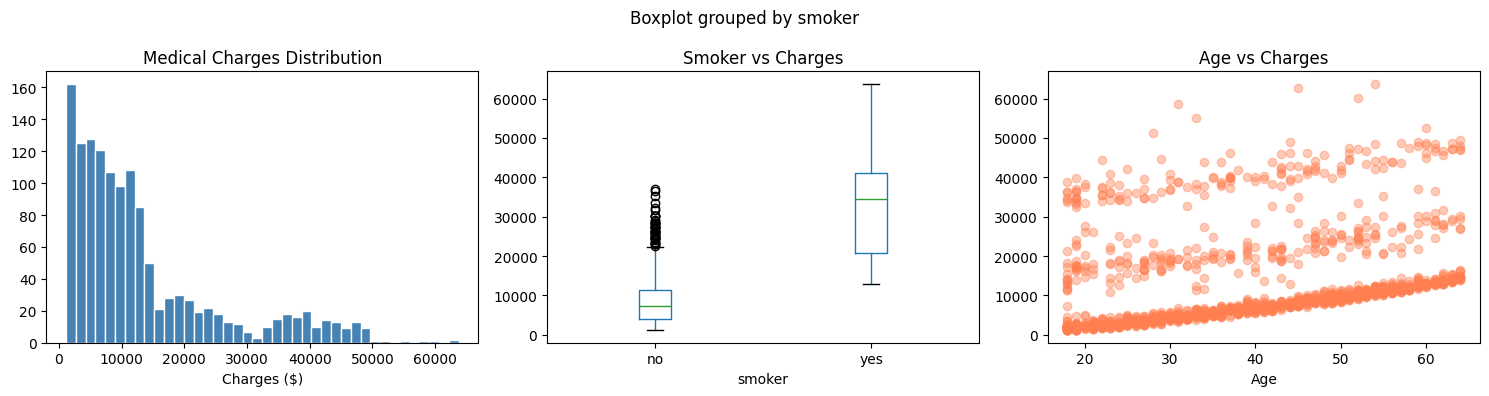

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Distribution of charges
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Medical Charges Distribution")
axes[0].set_xlabel("Charges ($)")

# Chart 2: Smoker vs Charges
df.boxplot(column='charges', by='smoker', ax=axes[1], grid=False)
axes[1].set_title("Smoker vs Charges")

# Chart 3: Age vs Charges
axes[2].scatter(df['age'], df['charges'], alpha=0.4, color='coral')
axes[2].set_title("Age vs Charges")
axes[2].set_xlabel("Age")

plt.tight_layout()
plt.show()

In [11]:
df_model = df.copy()
le = LabelEncoder()

df_model['sex']    = le.fit_transform(df_model['sex'])
df_model['smoker'] = le.fit_transform(df_model['smoker'])
df_model['region'] = le.fit_transform(df_model['region'])

print("Encoding done")
df_model.head()

Encoding done


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [12]:
X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Model trained
Training samples: 1070
Testing samples : 268


In [15]:
# Format: age, sex(0=female,1=male), bmi, children, smoker(0=no,1=yes), region(0-3)
new_patient = pd.DataFrame(
    [[35, 0, 28.5, 0, 1, 2]],
    columns=X.columns
)

cost = model.predict(new_patient)[0]
print(f"Predicted Medical Cost: ${cost:,.2f}")

Predicted Medical Cost: $29,725.38
